In [1]:
import json
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 
# 1. Detect where we are
current_dir = os.getcwd()
if current_dir.endswith("experiments/results"):
    RESULTS_DIR = "." # We are already there
else:
    RESULTS_DIR = "experiments/results"

# 2. Grab files
list_of_files = glob.glob(os.path.join(RESULTS_DIR, "*.json"))

if not list_of_files:
    print(f"DEBUG: Searching in: {os.path.abspath(RESULTS_DIR)}")
    print(f"DEBUG: Files in current dir: {os.listdir('.')}")
    raise FileNotFoundError(f"Still no .json files found. Check your terminal to see where the files are.")

# 3. Get the latest
latest_file = max(list_of_files, key=os.path.getctime)

print(f"📊 Found {len(list_of_files)} files. Loading: {latest_file}")

with open(latest_file, 'r') as f:
    payload = json.load(f)

df = pd.DataFrame(payload['results'])
meta = payload['metadata']

print(f"Done. Loaded experiment '{meta['name']}'")
df.head()


📊 Found 1 files. Loading: ./baseline_bm25.json
Done. Loaded experiment 'baseline_bm25'


,k,query,query_len,expected_course,found_course,expected_id,found_id,success,score,latency_ms,edit_distance,tokens_est
0,1,Course - When does the course start?,36,data-engineering-zoomcamp,data-engineering-zoomcamp,ff882002b31425f9e72726cba9aeebe1,071ea213dbd1d18cc34556acf1159a55,False,412.96716,6.28,423,114
1,1,Course - What are the prerequisites for this c...,52,data-engineering-zoomcamp,data-engineering-zoomcamp,591653d94a0ea9b5d85a16f65fea52a9,7a9144107b3ee2759085093a503d13a7,False,637.51510,2.94,10,15
2,1,Course - Can I still join the course after the...,58,data-engineering-zoomcamp,data-engineering-zoomcamp,64ffc7d1ca671d36b8029dbaa46fb90f,64ffc7d1ca671d36b8029dbaa46fb90f,True,817.43330,3.65,151,52
3,1,Course - I have registered for the Data Engine...,114,data-engineering-zoomcamp,data-engineering-zoomcamp,2b2f08c42dbf1ca63c229833e8b3604a,2b2f08c42dbf1ca63c229833e8b3604a,True,1093.52450,3.63,108,55
4,1,Course - What can I do before the course starts?,48,data-engineering-zoomcamp,data-engineering-zoomcamp,71882f8cefc0ed41dfa84d13cdf56aab,7eddf712a44669e30e30fcbd3d02bee7,False,700.38794,3.98,212,65


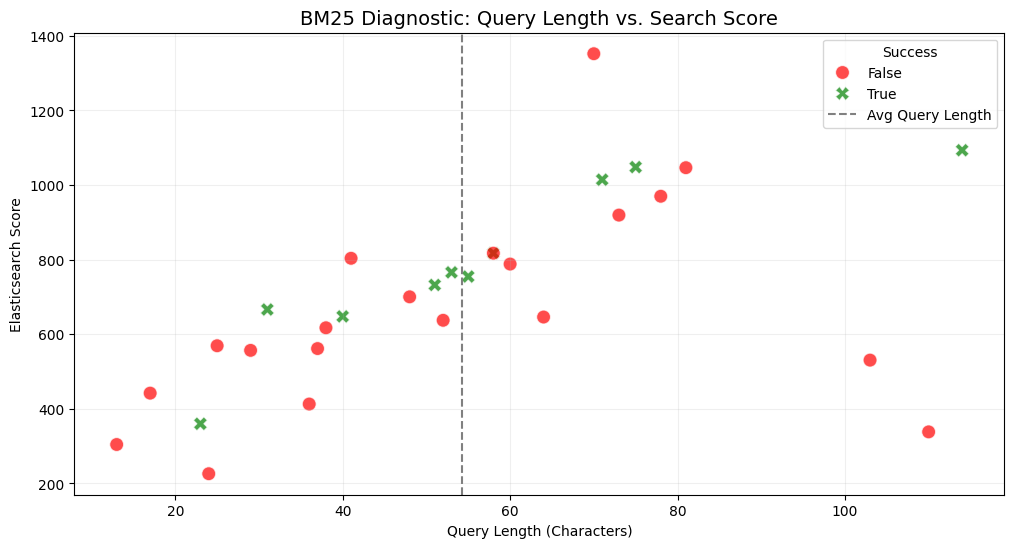

In [2]:
plt.figure(figsize=(12, 6))
# We look at K=5 to see general ranking health
k5_df = df[df['k'] == 5]

sns.scatterplot(
    data=k5_df, 
    x='query_len', 
    y='score', 
    hue='success', 
    style='success', 
    palette={True: 'green', False: 'red'},
    s=100, alpha=0.7
)

plt.axvline(x=k5_df['query_len'].mean(), color='gray', linestyle='--', label='Avg Query Length')
plt.title('BM25 Diagnostic: Query Length vs. Search Score', fontsize=14)
plt.xlabel('Query Length (Characters)')
plt.ylabel('Elasticsearch Score')
plt.grid(True, alpha=0.2)
plt.legend(title="Success")
plt.show()


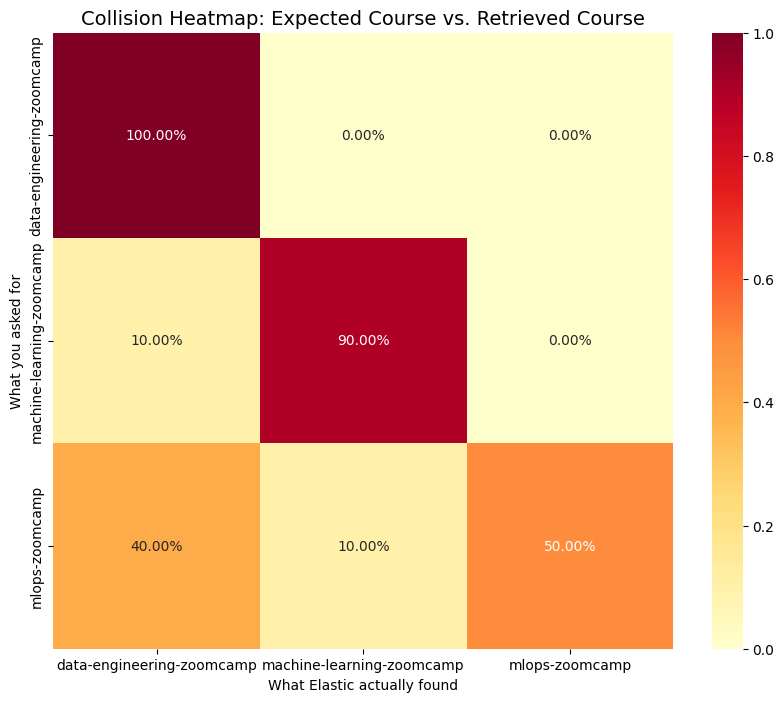

In [3]:
plt.figure(figsize=(10, 8))
# Crosstab shows Expected Course vs Found Course
collision_data = pd.crosstab(
    df['expected_course'], 
    df['found_course'], 
    normalize='index' # Shows percentages
)

sns.heatmap(collision_data, annot=True, cmap='YlOrRd', fmt='.2%')
plt.title('Collision Heatmap: Expected Course vs. Retrieved Course', fontsize=14)
plt.ylabel('What you asked for')
plt.xlabel('What Elastic actually found')
plt.show()


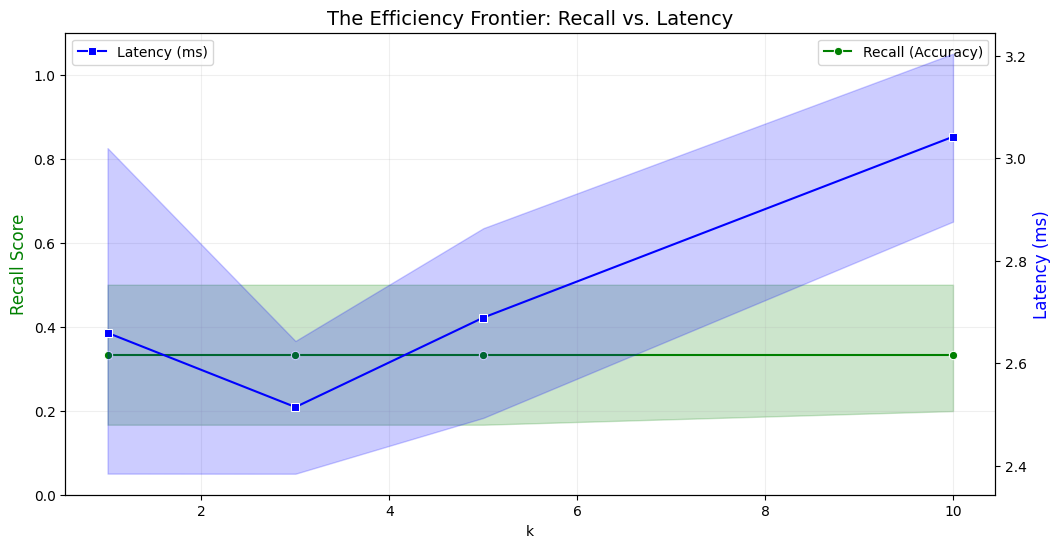

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Recall
sns.lineplot(data=df, x='k', y='success', ax=ax1, color='green', marker='o', label='Recall (Accuracy)')
ax1.set_ylabel('Recall Score', color='green', fontsize=12)
ax1.set_ylim(0, 1.1)

# Plot Latency on a second axis
ax2 = ax1.twinx()
sns.lineplot(data=df, x='k', y='latency_ms', ax=ax2, color='blue', marker='s', label='Latency (ms)')
ax2.set_ylabel('Latency (ms)', color='blue', fontsize=12)

plt.title('The Efficiency Frontier: Recall vs. Latency', fontsize=14)
ax1.grid(True, alpha=0.2)
plt.show()


In [5]:
# Copy/Paste this output to me
print(df.groupby('k')['success'].mean())
print("\nError distribution per course (at K=5):")
print(df[df['k']==5].groupby('expected_course')['success'].mean())


k
1     0.333333
3     0.333333
5     0.333333
10    0.333333
Name: success, dtype: float64

Error distribution per course (at K=5):
expected_course
data-engineering-zoomcamp    0.5
machine-learning-zoomcamp    0.4
mlops-zoomcamp               0.1
Name: success, dtype: float64


In [6]:
import os
import json
from elasticsearch import Elasticsearch

# 1. Find the project root
current_path = os.getcwd()
while not os.path.exists(os.path.join(current_path, 'documents.json')):
    parent = os.path.dirname(current_path)
    if parent == current_path: break
    current_path = parent

PROJECT_ROOT = current_path
# Adjust this filename if yours is named differently (e.g. settings_es.json)
CONFIG_PATH = os.path.join(PROJECT_ROOT, "experiments", "configs", "baseline_bm25.json")

# 2. Load and Debug Keys
with open(CONFIG_PATH, 'r') as f:
    settings = json.load(f)

print(f"DEBUG: Keys found in config: {list(settings.keys())}")

# 3. Connect (Using flexible key lookups)
es_host = settings.get('es_host', 'http://localhost:9200')
# Fallback to 'course-questions' if index_name isn't in your JSON
index_name = settings.get('index_name', settings.get('index', 'course-questions'))

es_client = Elasticsearch(es_host)

# 4. Run the Integrity Check
missing_ids = []
unique_evals = df[df['k'] == 1][['expected_id', 'query', 'expected_course']].to_dict('records')

print(f"--- 🔍 Verifying IDs in Index: '{index_name}' ---")

for item in unique_evals:
    if not es_client.exists(index=index_name, id=item['expected_id']):
        missing_ids.append(item)

if missing_ids:
    print(f"❌ FAILED: {len(missing_ids)} IDs are missing from the index.")
    print(f"Sample Missing ID: {missing_ids[0]['expected_id']}")
else:
    print(f"✅ SUCCESS: All {len(unique_evals)} IDs exist in the index.")


DEBUG: Keys found in config: ['es_host', 'course_name', 'search_size', 'boost_question', 'boost_text', 'search_type']
--- 🔍 Verifying IDs in Index: 'course-questions' ---
❌ FAILED: 20 IDs are missing from the index.
Sample Missing ID: ff882002b31425f9e72726cba9aeebe1


In [7]:
# Atomic Sanity Check Loop
missing_ids = []
total_checked = len(df[df['k'] == 1])

print(f"--- 🔍 Verifying {total_checked} IDs in Index: '{manager.index_name}' ---")

# We only need to check each unique expected_id once
unique_evals = df[df['k'] == 1][['expected_id', 'query', 'expected_course']].to_dict('records')

for item in unique_evals:
    exists = manager.es_client.exists(index=manager.index_name, id=item['expected_id'])
    if not exists:
        missing_ids.append(item)

if missing_ids:
    print(f"❌ FAILED: {len(missing_ids)} IDs are missing from the index.")
    print(f"First missing example: {missing_ids[0]['expected_id']} ({missing_ids[0]['expected_course']})")
    print("\n💡 ACTION: You MUST re-run ingest_data.py. Your Evaluation and Ingestion hashes are out of sync.")
else:
    print(f"✅ SUCCESS: All {total_checked} IDs exist in the index.")
    print("\n💡 ACTION: The 33% recall is a SEARCH problem. Your filters or weights are blocking the results.")


NameError: name 'manager' is not defined